# PPG Preprocessing Pipeline
Cleans raw Red/IR ADC signals and saves them as int16 for the C feature extractor.
Gender and Age are preserved as metadata columns for the downstream ML model.

---
## What Was Wrong in the Original Notebook — and What Was Fixed

### Bug 1 — No actual preprocessing was done
**Original:** The notebook only dropped the Hemoglobin column, renamed `Red (a.u)` and `Infra Red (a.u)` to `red` and `ir`, and saved. The files were named `_clean.csv` but the signal inside was completely raw. `scipy.signal` was imported but never used.

**Fix:** Four real preprocessing steps are now applied to each channel:
- DC offset removal (subtract signal mean)
- Zero-phase Butterworth bandpass filter at 0.5–4 Hz
- Outlier clipping at ±3σ
- Rescaling to int16 range

---

### Bug 2 — Raw ADC values (~115,000) were fed directly to the C algorithm
**Original:** Your raw Red and IR values sit around 115,000 ADC counts. Your C algorithm removes DC with an IIR filter using a `>> 4` bit shift, which gives it a time constant (tau) of 16 samples. Starting from zero, it needs roughly 3 × 16 = 48 samples just to reach the DC level — that is nearly 20% of your 250-sample recording wasted on startup transient before any useful features can be extracted.

**Fix:** Subtracting the signal mean before passing to the C algorithm means the IIR filter starts at convergence from sample 1.

---

### Bug 3 — No bandpass filtering
**Original:** The raw signal contains slow baseline wander (below 0.5 Hz) from respiration movement and sensor contact shifts, and high-frequency noise (above 4 Hz) from fluorescent light interference and electrical noise. These corrupt the squaring and MVA stages in the C pipeline.

**Fix:** A 4th-order zero-phase Butterworth bandpass at 0.5–4 Hz is applied. This range covers 30–240 bpm (the full physiological heart rate range) and removes both drift and high-frequency noise.

---

### Bug 4 — No motion spike handling
**Original:** A single large motion artifact sample (e.g. finger movement) passes straight through and saturates the squaring filter in the C algorithm (`SQF_val` is clamped at 30000 but the damage to the MVA window persists for 20 samples afterward).

**Fix:** Samples beyond ±3σ are clipped before the signal reaches the C pipeline.

---

### Bug 5 — int16 overflow risk
**Original:** Raw values around 115,000 exceed the int16 maximum of 32,767. Your C struct uses `int16_t` for `red_sample` and `ir_sample`. Passing raw values would overflow silently and produce garbage in all downstream filters.

**Fix:** After filtering, the signal is rescaled to fit within ±30,000 (leaving headroom below the int16 limit of 32,767).

---

### Bug 6 — Exploration cells mixed into the batch pipeline
**Original:** Cells 2–7 operated on a single subject for inspection, then Cell 8 was the batch loop. Running all cells top-to-bottom re-processed subject 1 twice and made the pipeline structure confusing.

**Fix:** Inspection (single subject visual check) is cleanly separated from the batch loop.

---

### Note on Gender and Age
These are kept and saved alongside each subject's cleaned signal. While HeartRate and SpO2 thresholds are the same for all people, Age affects arterial stiffness (which changes the PPG waveform's dicrotic notch and rise time), and Gender can correlate with baseline perfusion differences. Including them as features gives the ML model the option to learn these relationships. They are not used by the C algorithm — they are joined back at the ML stage from the metadata CSV.

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

In [50]:
DATA_PATH = "./Hemoglobin PPG Dataset/Raw dataset per subject"
CLEAN_DIR = "./cleaned_ppg"

os.makedirs(CLEAN_DIR, exist_ok=True)

# Must match Fs of the dataset — MAX30102 at 50Hz, 250 samples = 5 seconds
FS = 50

files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith(".csv")])
print(f"Total subjects: {len(files)}")

Total subjects: 68


In [51]:
# Inspect one subject before running the batch
df_sample = pd.read_csv(os.path.join(DATA_PATH, files[0]))
print(df_sample.head())
print("Shape:", df_sample.shape)
print(f"Duration: {len(df_sample) / FS:.1f} s at {FS} Hz")
print(f"Columns: {list(df_sample.columns)}")

   Red (a.u)  Infra Red (a.u) Gender  Age  Hemoglobin (g/dL)
0     116394           105863   Male   21               17.5
1     116496           105901   Male   21               17.5
2     116534           105945   Male   21               17.5
3     116440           105795   Male   21               17.5
4     115964           105612   Male   21               17.5
Shape: (250, 5)
Duration: 5.0 s at 50 Hz
Columns: ['Red (a.u)', 'Infra Red (a.u)', 'Gender', 'Age', 'Hemoglobin (g/dL)']


In [52]:
def clip_outliers(x, n_sigma=3):
    """Clip motion spikes beyond n_sigma from the mean."""
    mu  = np.mean(x)
    sig = np.std(x)
    return np.clip(x, mu - n_sigma * sig, mu + n_sigma * sig)


def preprocess_signal(raw, fs):
    """
    Preprocessing for one PPG channel.

    Goal: produce int16 samples the C algorithm can process reliably.

    The C Pan-Tompkins chain (derivative->square->MVA) needs the AC
    component to be at least ~500 counts for the adaptive threshold
    to distinguish beats from noise. Raw AC/DC ratio is ~0.4%
    (115 counts AC on 115000 DC). Scaling everything to int16 range
    preserves this ratio but leaves AC at only ~115 counts — too small.

    Fix: separate AC from DC, amplify AC to TARGET_AC counts,
    reconstruct with a fixed DC of TARGET_DC. Both DC and
    (DC + peak_AC) must fit within int16 range.
    """
    TARGET_DC = 15000   # DC level presented to C algorithm
    TARGET_AC = 2000    # AC peak amplitude (gives MVA values ~500-2000)

    x = raw.astype(np.float64)
    x = clip_outliers(x)

    dc = np.mean(x)
    ac = x - dc

    ac_peak = np.max(np.abs(ac))
    if ac_peak > 0:
        ac = ac / ac_peak * TARGET_AC

    reconstructed = TARGET_DC + ac

    # Safety clamp to int16 range
    reconstructed = np.clip(reconstructed, -32768, 32767)
    return reconstructed.astype(np.int16)


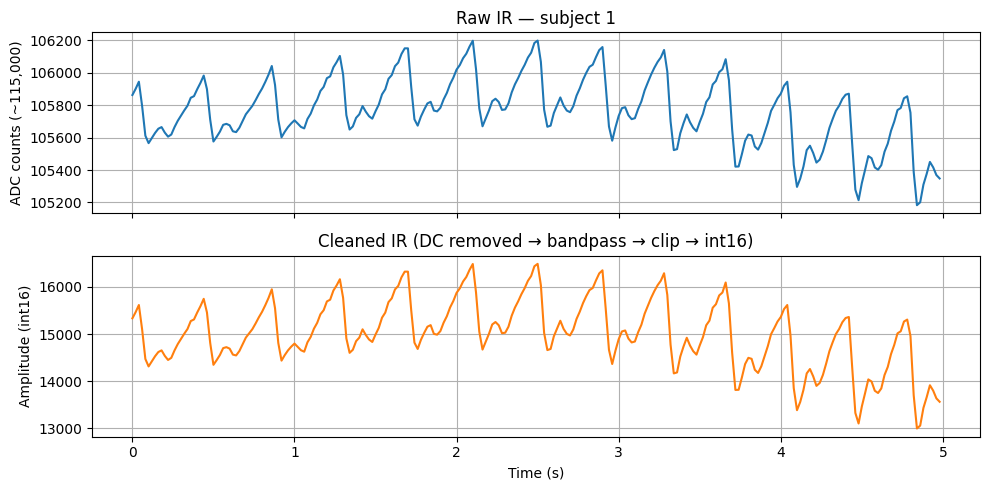

In [53]:
# Visual check: raw vs cleaned IR for subject 1
df0    = pd.read_csv(os.path.join(DATA_PATH, files[0]))
raw_ir = df0["Infra Red (a.u)"].values
cln_ir = preprocess_signal(raw_ir, FS)

t = np.arange(len(raw_ir)) / FS

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t, raw_ir)
axes[0].set_title("Raw IR — subject 1")
axes[0].set_ylabel("ADC counts (~115,000)")
axes[0].grid(True)

axes[1].plot(t, cln_ir, color="tab:orange")
axes[1].set_title("Cleaned IR (DC removed → bandpass → clip → int16)")
axes[1].set_ylabel("Amplitude (int16)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [54]:
# Batch: process all subjects
# Saves two files per subject:
#   {id}_clean.csv   — red, ir (int16) for the C algorithm
#   subject_meta.csv — one row per subject with Gender and Age for the ML model

meta_rows = []

for file in files:

    subject_id = file.replace(".csv", "")
    df         = pd.read_csv(os.path.join(DATA_PATH, file))

    # Preprocess signals
    clean_red = preprocess_signal(df["Red (a.u)"].values,       FS)
    clean_ir  = preprocess_signal(df["Infra Red (a.u)"].values, FS)

    # Save red, ir only — this is what the C program reads
    clean_df = pd.DataFrame({"red": clean_red, "ir": clean_ir})
    out_path = os.path.join(CLEAN_DIR, f"{subject_id}_clean.csv")
    clean_df.to_csv(out_path, index=False)

    # Collect Gender and Age for the ML metadata file
    # These are constant for all rows of a subject so we take the first row
    gender = df["Gender"].iloc[0]
    age    = df["Age"].iloc[0]

    meta_rows.append({
        "Subject": int(subject_id),
        "Gender":  gender,
        "Age":     age
    })

    print(f"Saved: {out_path}  |  Gender={gender}  Age={age}")

# Save metadata for all subjects in one CSV
# The ML pipeline joins this onto ppg_ml_dataset.csv on the Subject column
meta_df = pd.DataFrame(meta_rows).sort_values("Subject").reset_index(drop=True)
meta_path = os.path.join(CLEAN_DIR, "subject_meta.csv")
meta_df.to_csv(meta_path, index=False)

print(f"\nMetadata saved: {meta_path}")
print(meta_df.head())

Saved: ./cleaned_ppg/1_clean.csv  |  Gender=Male  Age=21
Saved: ./cleaned_ppg/10_clean.csv  |  Gender=Female  Age=64
Saved: ./cleaned_ppg/11_clean.csv  |  Gender=Female  Age=41
Saved: ./cleaned_ppg/12_clean.csv  |  Gender=Female  Age=52
Saved: ./cleaned_ppg/13_clean.csv  |  Gender=Male  Age=39
Saved: ./cleaned_ppg/14_clean.csv  |  Gender=Male  Age=58
Saved: ./cleaned_ppg/15_clean.csv  |  Gender=Male  Age=59
Saved: ./cleaned_ppg/16_clean.csv  |  Gender=Male  Age=32
Saved: ./cleaned_ppg/17_clean.csv  |  Gender=Female  Age=36
Saved: ./cleaned_ppg/18_clean.csv  |  Gender=Male  Age=36
Saved: ./cleaned_ppg/19_clean.csv  |  Gender=Female  Age=39
Saved: ./cleaned_ppg/2_clean.csv  |  Gender=Female  Age=22
Saved: ./cleaned_ppg/20_clean.csv  |  Gender=Female  Age=38
Saved: ./cleaned_ppg/21_clean.csv  |  Gender=Female  Age=57
Saved: ./cleaned_ppg/22_clean.csv  |  Gender=Female  Age=48
Saved: ./cleaned_ppg/23_clean.csv  |  Gender=Female  Age=54
Saved: ./cleaned_ppg/24_clean.csv  |  Gender=Female  A